In [18]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [7]:
!pip install xgboost lightgbm -q

In [9]:
data =load_breast_cancer(as_frame=True)
df = data.frame

In [10]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
X = df.drop("target",axis = 1)
y = df["target"]

X_train ,X_test , y_train ,y_test = train_test_split(X , y , test_size=0.2 , random_state= 42,stratify= y)


In [17]:
rf = RandomForestClassifier()
rf.fit(X_train , y_train)
rf_prediction = rf.predict(X_test)

In [19]:
print("Accuracy Score : " , accuracy_score(y_test ,rf_prediction))
print("Classification Report : \n" , classification_report(y_test ,rf_prediction))

Accuracy Score :  0.9473684210526315
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [20]:
xgb = XGBClassifier()
xgb.fit(X_train , y_train)
xgb_pred = xgb.predict(X_test)

In [21]:
print("Accuracy Score : " , accuracy_score(y_test ,xgb_pred))
print("Classification Report : \n" , classification_report(y_test ,xgb_pred))

Accuracy Score :  0.956140350877193
Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [22]:
lg = LGBMClassifier()
lg.fit(X_train , y_train)
lg_pred = lg.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [23]:
print("Accuracy Score : " , accuracy_score(y_test ,lg_pred))
print("Classification Report : \n" , classification_report(y_test ,lg_pred))

Accuracy Score :  0.9649122807017544
Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [25]:
comparison = pd.DataFrame({
    "model": ["Random Forest", "XGBoost" , "LightGBM"],
    "Accuracy" : [accuracy_score(y_test ,rf_prediction) , accuracy_score(y_test ,xgb_pred),accuracy_score(y_test ,lg_pred)]
})

In [26]:
comparison

,model,Accuracy
0,Random Forest,0.947368
1,XGBoost,0.956140
2,LightGBM,0.964912


In [73]:
train_df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

In [80]:
print(train_df["Churn"].isnull().sum())
print(test_df["Churn"].isnull().sum())

1
0


In [81]:
train_df[train_df["Churn"].isnull()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
train_df = train_df.dropna(subset=["Churn"])

In [83]:
train_df[train_df["Churn"].isnull()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [84]:
X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

In [85]:
X_train = pd.get_dummies(X_train,columns=["Gender", "Subscription Type", "Contract Length"],drop_first=True)

X_test = pd.get_dummies(X_test,columns=["Gender", "Subscription Type", "Contract Length"],drop_first=True)

In [86]:
X_train, X_test = X_train.align(X_test,join="left",axis=1,fill_value=0)

In [88]:
rf =RandomForestClassifier()
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [89]:
xgb =XGBClassifier()
xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)

In [90]:
lg =LGBMClassifier()
lg.fit(X_train,y_train)
lg_pred = lg.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 249999, number of negative: 190833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 734
[LightGBM] [Info] Number of data points in the train set: 440832, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567107 -> initscore=0.270058
[LightGBM] [Info] Start training from score 0.270058


In [92]:
comp = pd.DataFrame({
    "Models" : ["RandomFores" , "XGBClassifier" , "LGBMClassifier"],
    "Accuracy" : [accuracy_score(y_test , rf_pred) , accuracy_score(y_test , xgb_pred),accuracy_score(y_test,lg_pred)]
})

In [93]:
comp

,Models,Accuracy
0,RandomFores,0.496427
1,XGBClassifier,0.503247
2,LGBMClassifier,0.503076


<Axes: >

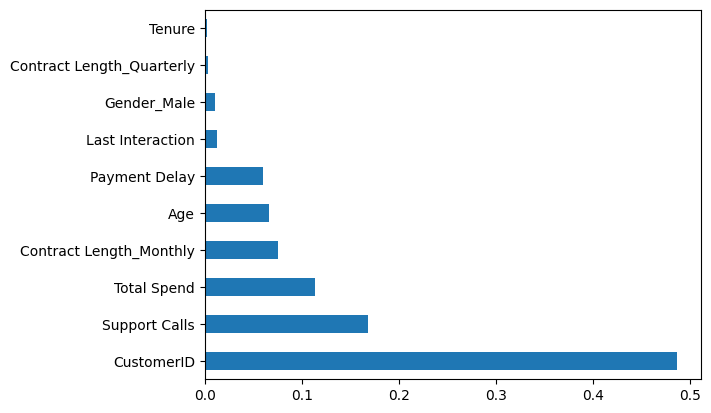

In [95]:
important = pd.Series(rf.feature_importances_, index=X.columns)

important.sort_values(ascending=False).head(10).plot.barh()